# Tarea 1: DSP Exercise Set: Signals & Time-Domain Analysis

Materia: Procesamiento Digital de Señales

Grupo: 03

### Integrantes:
* Espinoza Matamoros Percival Ulises
* Lugo Manzano Rodrigo
* García Cortés Adolfo de Jésus

## Link Video Explicación
[Video Explicando la Tarea1](https://www.youtube.com/watch?v=epkC8jQnW58)


## Importacion y Configuracion Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 3)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=4, suppress=True)

In [2]:
# Funciones

# Funcion Escalon usando la definicion:
def funcion_escalon(n):
  if n >= 0:
    return 1
  else:
    return 0

# Funcion Impuslo usando la definicion:
def funcion_impulso(n):
  if n == 0:
    return 1
  else:
    return 0

def inversion_tiempo(n, xn):
  inv_t = []
  n_inv = []

  # Invirtiendo la listas: de n y xn
  for i in range(len(n)):
    j = (len(n) - 1) - i
    inv_t.append(xn[j])

  for i in range(len(n)):
    j = (len(n) - 1) - i
    n_inv.append(n[j] * -1)

  return inv_t, n_inv

def desplazamiento(xn, n, k):
    xn_desp = list(xn)
    n_desp = list(n)

    if k > 0:
        xn_ceros = []
        for i in range(k):
            xn_ceros.append(0)

        # Agregar Ceros al Inicio
        xn_desp = xn_ceros + xn_desp

        # Tiempos a la derecha
        ultimo_tiempo = n[-1]
        n_extra = []
        for i in range(1, k + 1):
            nuevo_tiempo = ultimo_tiempo + i
            n_extra.append(nuevo_tiempo)

        # Agregar los nuevos tiempos al final
        n_desp = n_desp + n_extra

    elif k < 0:
        k_abs = abs(k)

        xn_ceros = []
        for i in range(k_abs):
            xn_ceros.append(0)

        # Agregar Ceros al Final
        xn_desp = xn_desp + xn_ceros

        primer_tiempo = n[0]
        n_extra = []

        for i in range(k_abs, 0, -1):
            nuevo_tiempo = primer_tiempo - i
            n_extra.append(nuevo_tiempo)

        # Agregar los nuevos tiempos al inicio
        n_desp = n_extra + n_desp

    return xn_desp, n_desp

In [3]:
def energia(xn):
  energia = 0.0

  for amplitud in xn:
    # E = Σ {x^2 [N]}
    energia = energia + (amplitud ** 2)

  return energia

def potencia(xn):
  N = len(xn)

  if N == 0:
      return 0.0

  E = energia(xn)
  # E = (1 / 2N + 1) Σ {x^2 [N]}
  # Al tener la longitud de xn en un arreglo ya no es necesario 2N + 1
  potencia = E / N

  return potencia

# Excercise 1:
For each of the following signals, determine whether it is continuous/discrete, periodic/aperiodic, and causal/non-causal:



a) $x(t) = sin (2 \pi 10t)$

Es una señal **continua**
Tiene una forma de una señal sinusoidal $x(t)=Asin(\omega t + \phi)$

Donde $\omega = 2\pi f$  $\rightarrow$ $f = 10 [Hz]$

$T= \frac{1}{f} = \frac{1}{10} = 0.1 [s]$

Es una señal **continua**


/tmp/ipykernel_2306/4270383395.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


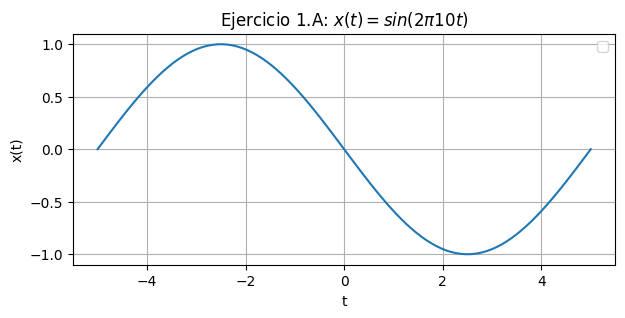

In [4]:
## Grafica: Ejercicio 1.a

f = 10
eje_x = np.linspace(-5, 5, 100)
eje_y = np.sin(2*np.pi*f*eje_x)

plt.plot(eje_x, eje_y)
plt.title(r"Ejercicio 1.A: $x(t) = sin (2 \pi 10t)$")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.legend()
plt.show()

A partir de la gráfica se puede concluir que: Es **periodica** porque es infinita y **No Causal** ya que al ser negativa tiene parte negativa.

b) $x[n] = u[n-3]$

Es una señal **discreta**

/tmp/ipykernel_2306/3773878170.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


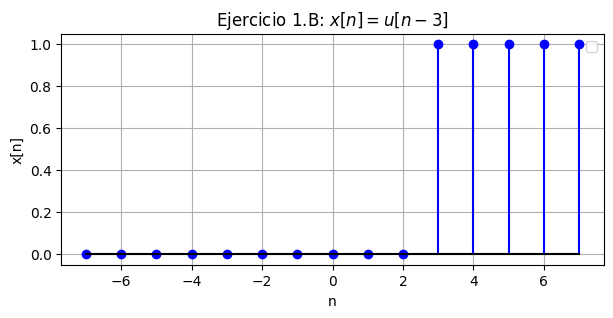

In [5]:
## Grafica: Ejercicio 1.b
eje_x = np.arange(-7, 8, 1)
eje_y = []
# Por cada elemento de la lista con los valores del eje_x se llama a la función escalón y el resulado se guarda en una lista
for n in eje_x:
  eje_y.append(funcion_escalon(n-3))

plt.stem(eje_x, eje_y, linefmt='blue', markerfmt='b', basefmt='black')
plt.title(r"Ejercicio 1.B: $x[n] = u[n-3]$")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.grid(True)
plt.legend()
plt.show()


A partir de la gráfica se puede concluir que: Es **aperiodica** porque en los negativos vale $0$ y además es **causal** porque no tiene valiores negativos

c) $x(t) = {e}^{-t}u(t)$

Es una señal **continua**

/tmp/ipykernel_2306/4114225972.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


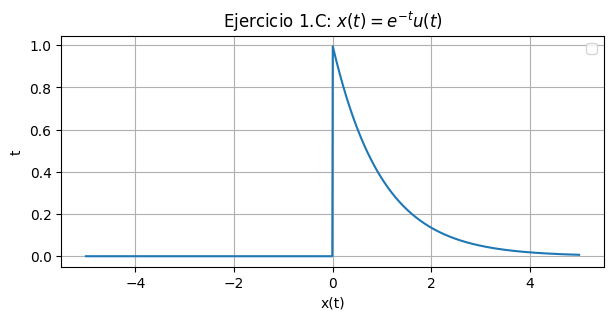

In [6]:
## Grafica: Ejercicio 1.c
eje_x = np.linspace(-5, 5, 1000)
eje_y = []
# Por cada elemento de la lista con los valores del eje_x se llama a la función escalón y exponencial
for t in eje_x:
  eje_y.append(np.exp(-t)*funcion_escalon(t))

plt.plot(eje_x, eje_y)
plt.title(r"Ejercicio 1.C: $x(t) = {e}^{-t}u(t)$")
plt.xlabel("x(t)")
plt.ylabel("t")
plt.grid(True)
plt.legend()
plt.show()

A partir de la gráfica se puede concluir que: Es **aperiodica** por contener la función escalón unitario y además es **causal** porque no tiene valiores negativos

# Excercise 2:
Is the signal $x[n] = cos((5\pi /6)n)$ periodic? If yes, find its fundamental period.


$x[n] = cos(\frac{5 \pi}{6} \, n)$

Donde $\omega_o = \frac{5 \pi}{6}$

Aplicando la prueba de periodicidad:

$\frac{\omega_o}{2 \pi} = \frac{k}{N}$

$\frac{\omega_o}{2 \pi} = \frac{5 \pi /6}{2 \pi} = \frac{5 \pi}{12 \pi} = \frac{5}{12}$

Por lo tanto la señal **tiene periocididad** y su periodo fundamental es $N = 12$



/tmp/ipykernel_2306/2981962442.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


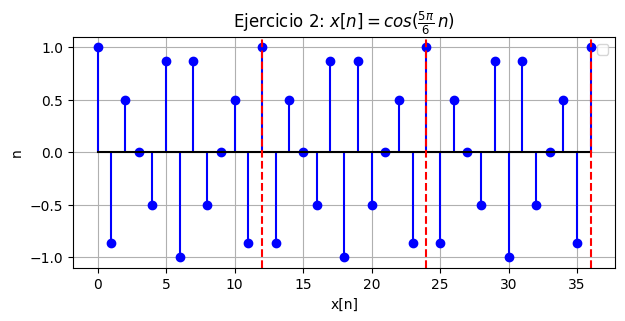

In [7]:
# Grafica para mostrar 3 periodos (3 *N -> 3 * 12 = 36)
N = 12
# Generacion del eje x para graficar 3 periodos
eje_x = np.arange(0, ((3 * N) + 1), 1)
# Obtener el eje y: cos(w_o * n)
eje_y = np.cos((5 * np.pi / 6) * eje_x)

plt.stem(eje_x, eje_y, linefmt='blue', markerfmt='b', basefmt='black')
# Periodos
plt.axvline(x=N, color='red', linestyle='--')
plt.axvline(x=N*2, color='red', linestyle='--')
plt.axvline(x=N*3, color='red', linestyle='--')

plt.title(r"Ejercicio 2: $x[n] = cos(\frac{5 \pi}{6} \, n)$")
plt.xlabel("x[n]")
plt.ylabel("n")
plt.grid(True)
plt.legend()
plt.show()

# Excercise 3:
A continuous-time signal $x(t) = cos(200\pi t)$ is sampled at $f_s = 150 [Hz]$.


**- What is the Nyquist rate?**

$200\pi t = 2 \pi f_o t → f_o = \frac{200 \pi t}{2 \pi t} = 100 [Hz]$

$f_{nyquist} \geq 2 f_{o}$

$f_{nyquist} \geq 2 \cdot 100[Hz]$

$f_{nyquist} \geq 200[Hz]$


**- Will aliasing occur? If so, what is the apparent frequency after sampling?**

**El aliasing va a ocurrir**, debido a que el teorema requireq eue la frecuencia de muestreo sea superior a la frecuencia de Nyquist para capturar la señal con precisión

De forma que en tenemos: $f_{nyquist} = 200[Hz]$ y $f_s = 150[Hz]$

**La frecuencia aparente es:**

$f_{aparente} = |f_{o} - f_s| = |100[Hz] - 150[Hz]| = 50 [Hz]$


# Excercise 4:
Sketch the following signals for -5 ≤ n ≤ 5:

a) $u[n]$

/tmp/ipykernel_2306/1622930223.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


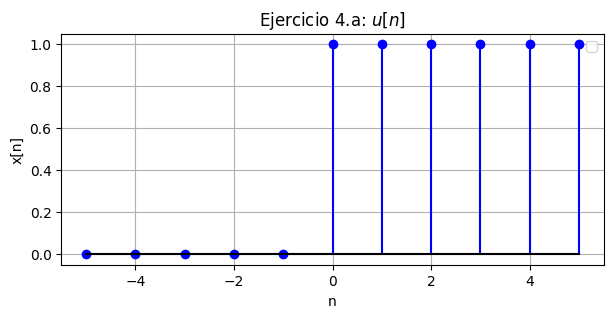

In [8]:
N = 5
# Generacion del eje x en el intervalo especificado
eje_x = np.arange(-N, (N + 1), 1)
eje_y = []

# A cada elemento del eje x (n) se le aplica la funcion escalon unitario
for n in eje_x:
  eje_y.append(funcion_escalon(n))

plt.stem(eje_x, eje_y, linefmt='blue', markerfmt='b', basefmt='black')
plt.title(r"Ejercicio 4.a: $u[n]$")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.grid(True)
plt.legend()
plt.show()


Comparando la gráfica con la gráfica obtenida a mano:

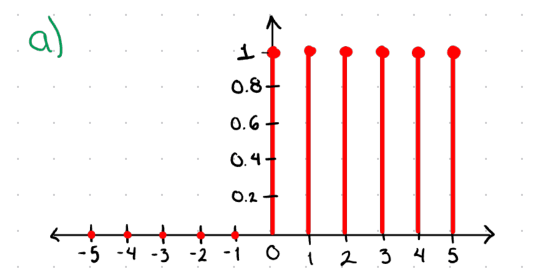

b) $δ[n]$

/tmp/ipykernel_2306/745414322.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


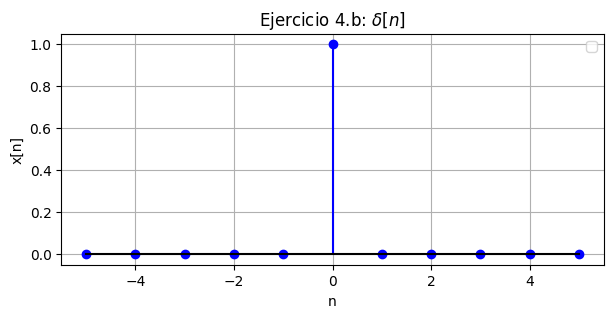

In [9]:
N = 5
# Generacion del eje x en el intervalo especificado
eje_x = np.arange(-N, (N + 1), 1)
eje_y = []
# A cada elemento del eje x (n) se le aplica la funcion escalon unitario
for n in eje_x:
  eje_y.append(funcion_impulso(n))

plt.stem(eje_x, eje_y, linefmt='blue', markerfmt='b', basefmt='black')
plt.title(r"Ejercicio 4.b: $\delta[n]$")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.grid(True)
plt.legend()
plt.show()

Comparando la gráfica con la gráfica obtenida a mano:

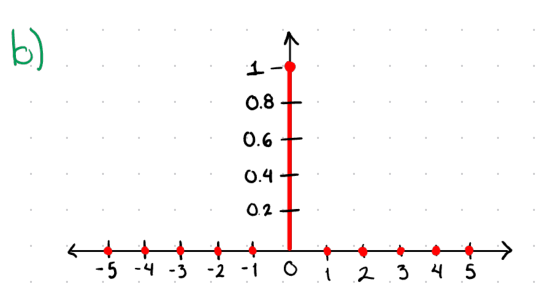

c) $r[n] = n \, u[n]$

/tmp/ipykernel_2306/2622500113.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


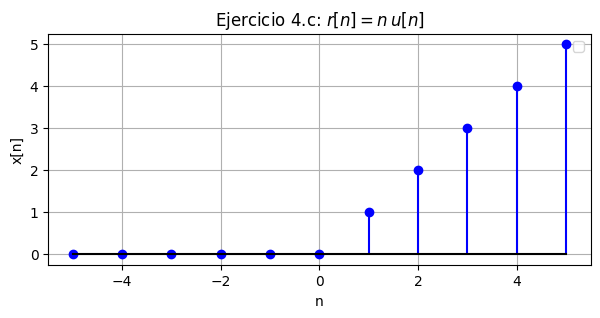

In [10]:
N = 5
# Generacion del eje x en el intervalo especificado
eje_x = np.arange(-N, (N + 1), 1)
eje_y = []
# A cada elemento del eje x (n) se le aplica la funcion escalon unitario * n (funcion rampa)
for n in eje_x:
  eje_y.append(n * funcion_escalon(n))

plt.stem(eje_x, eje_y, linefmt='blue', markerfmt='b', basefmt='black')
plt.title(r"Ejercicio 4.c: $r[n] = n \, u[n]$")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.grid(True)
plt.legend()
plt.show()

Comparando la gráfica con la gráfica obtenida a mano:

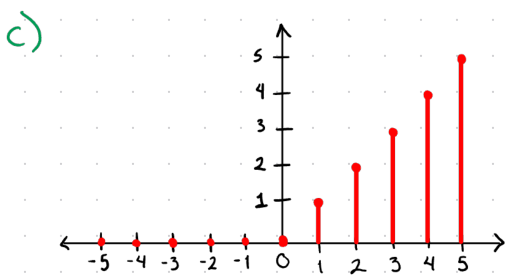

# Excercise 5:
Given $x[n] = \{1,2,3,4\}$ for $n=0,1,2,3$, compute and sketch $x[-n]$.

/tmp/ipykernel_2306/1088417584.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_2306/1088417584.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


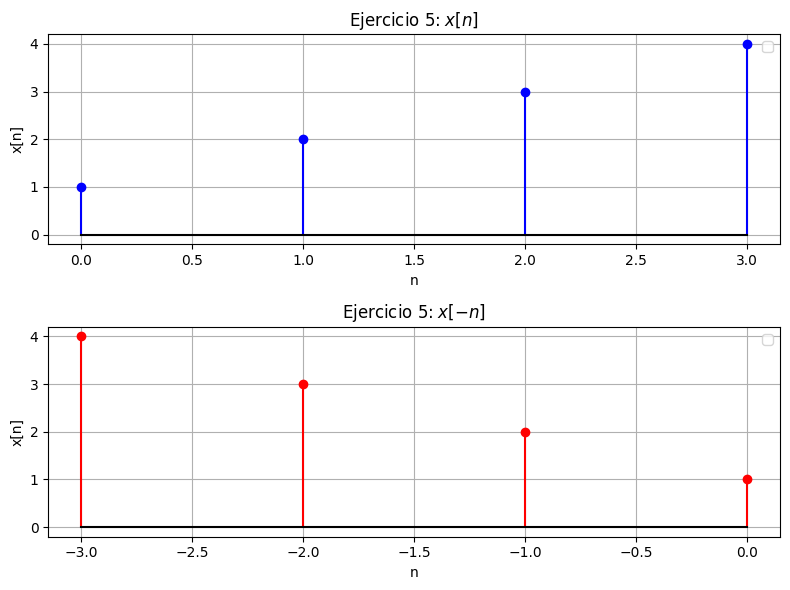

In [11]:
# Grafica: Ejercicio 5

# Definiendo la funciin discreta

n = [0, 1, 2, 3]
xn = [1, 2, 3, 4]
# Llamando a la funcion de inversion en el tiempo que se definiio al inicio
xn_inv, n_inv = inversion_tiempo(n, xn)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

ax1.stem(n, xn, linefmt='blue', markerfmt='b', basefmt='black')
ax1.set_title(r"Ejercicio 5: $x[n]$")
ax1.set_xlabel("n")
ax1.set_ylabel("x[n]")
ax1.grid(True)
ax1.legend()

ax2.stem(n_inv, xn_inv, linefmt='red', markerfmt='ro', basefmt='black')
ax2.set_title(r"Ejercicio 5: $x[-n]$")
ax2.set_xlabel("n")
ax2.set_ylabel("x[n]")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()



Comparando con la gráfica obtenida a mano

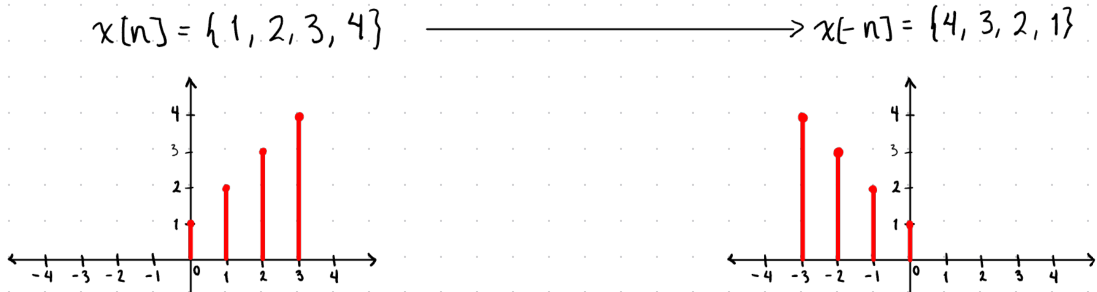

# Excercise 6:
For the same signal $x[n] = \{1,2,3,4\}$, compute and sketch:

a) $x[n-2]$


/tmp/ipykernel_2306/4152576867.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_2306/4152576867.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


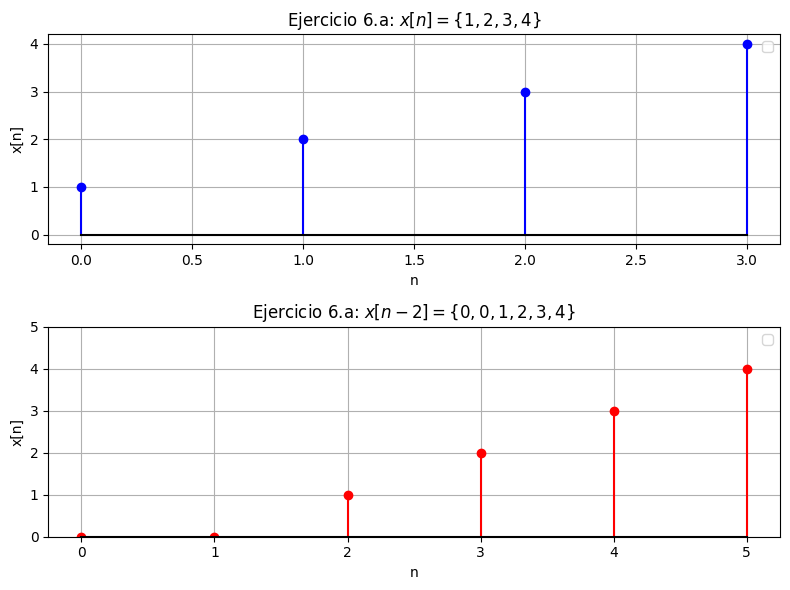

In [12]:
# Definiendo la funcion discreta
n = [0, 1, 2, 3]
xn = [1, 2, 3 ,4]
# Llamando a la funcion de desplazamiento en el tiempo que se definio al inicio
# Se implemento usando la fomra x[n-k]; si k =2 -> x[n-2]
xn_desplazamiento, n_2 = desplazamiento(xn, n, 2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
ax1.stem(n, xn, linefmt='blue', markerfmt='b', basefmt='black')
ax1.set_title(r"Ejercicio 6.a: $x[n] = \{1,2,3,4\}$")
ax1.set_xlabel("n")
ax1.set_ylabel("x[n]")
ax1.grid(True)
ax1.legend()

ax2.stem(n_2, xn_desplazamiento, linefmt='red', markerfmt='ro', basefmt='black')
ax2.set_title(r"Ejercicio 6.a: $x[n-2] = \{0,0,1,2,3,4\}$")
ax2.set_xlabel("n")
ax2.set_ylabel("x[n]")
ax2.set_ylim(0, 5)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

Grafias y resultados obtenidos en papel

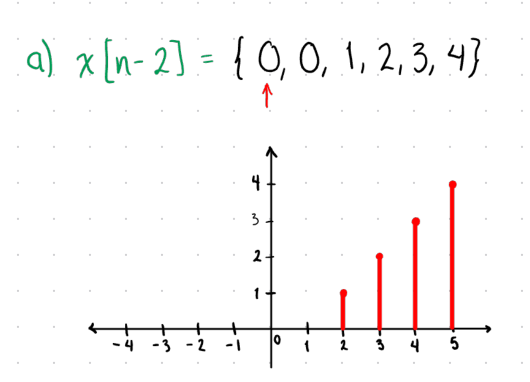


b) $x[n+1]$

/tmp/ipykernel_2306/1327331182.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_2306/1327331182.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


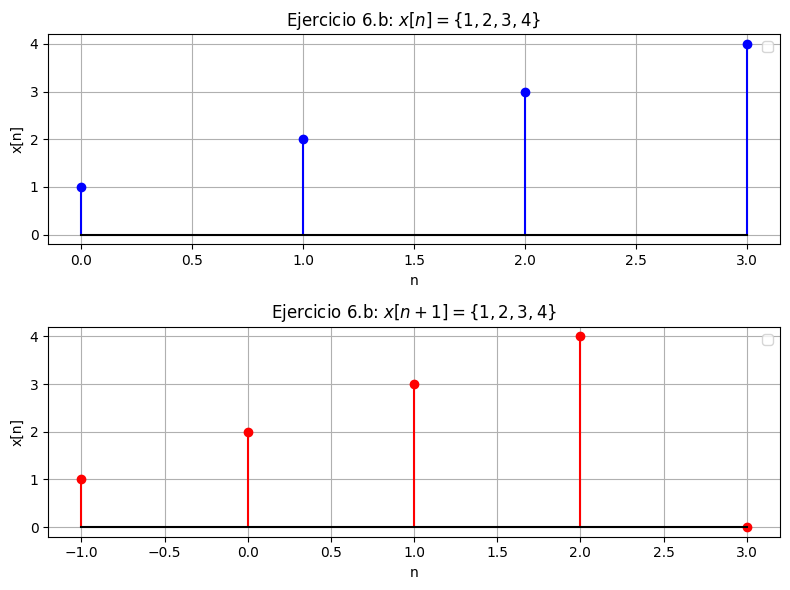

In [13]:
n = [0, 1, 2, 3]
xn = [1, 2, 3 ,4]
# Se implemento usando la fomra x[n-k]; si k = -1 -> x[n+1]
xn_desplazamiento, n_2 = desplazamiento(xn, n, -1)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

ax1.stem(n, xn, linefmt='blue', markerfmt='b', basefmt='black')
ax1.set_title(r"Ejercicio 6.b: $x[n] = \{1,2,3,4\}$")
ax1.set_xlabel("n")
ax1.set_ylabel("x[n]")
ax1.grid(True)
ax1.legend()

ax2.stem(n_2, xn_desplazamiento, linefmt='red', markerfmt='ro', basefmt='black')
ax2.set_title(r"Ejercicio 6.b: $x[n+1] = \{1,2,3,4\}$")
ax2.set_xlabel("n")
ax2.set_ylabel("x[n]")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

Grafica y Resultado obtenido en papel

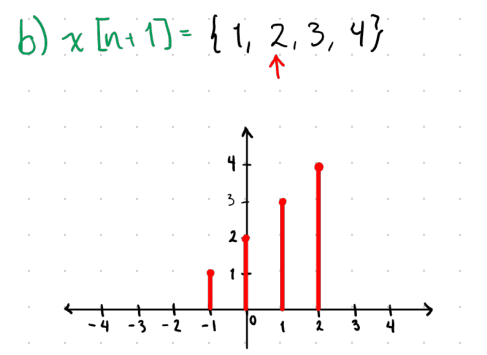


# Excercise 7:
Take $x[n] = \{1,2,3,4\}$. Compute and sketch:


a) $x[-n+2]$

/tmp/ipykernel_2306/1229160935.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_2306/1229160935.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_2306/1229160935.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()


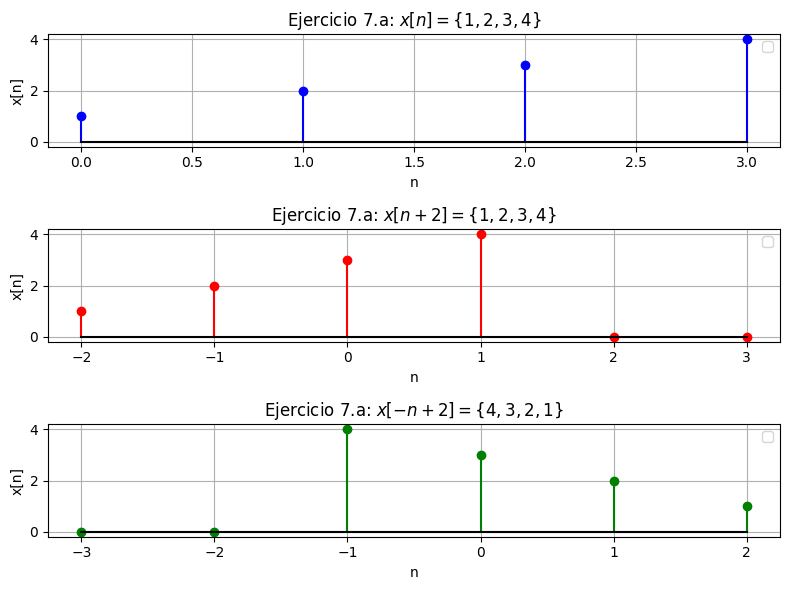

In [14]:
# Definiendo la funcion discreta
n = [0, 1, 2, 3]
xn = [1, 2, 3 ,4]

# Orden condiderando la combinación de transformaciones
# 1. Aplicar desplazamiento
# 2. Aplicar escalamiento / inversion

# Se implemento usando la fomra x[n-k]; si k =-2 -> x[n+2]
xn_desplazamiento, n_d = desplazamiento(xn, n, -2)
# Aplicando una inversion el tiempo
xn_des_inv, n_d_inv = inversion_tiempo(n_d, xn_desplazamiento)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 6))

ax1.stem(n, xn, linefmt='blue', markerfmt='b', basefmt='black')
ax1.set_title(r"Ejercicio 7.a: $x[n] = \{1,2,3,4\}$")
ax1.set_xlabel("n")
ax1.set_ylabel("x[n]")
ax1.grid(True)
ax1.legend()

ax2.stem(n_d, xn_desplazamiento, linefmt='red', markerfmt='ro', basefmt='black')
ax2.set_title(r"Ejercicio 7.a: $x[n+2] = \{1,2,3,4\}$")
ax2.set_xlabel("n")
ax2.set_ylabel("x[n]")
ax2.grid(True)
ax2.legend()

ax3.stem(n_d_inv, xn_des_inv, linefmt='green', markerfmt='g', basefmt='black')
ax3.set_title(r"Ejercicio 7.a: $x[-n+2] = \{4,3,2,1\}$")
ax3.set_xlabel("n")
ax3.set_ylabel("x[n]")
ax3.grid(True)
ax3.legend()

plt.tight_layout()
plt.show()

Resultado Obtenudo en papel:

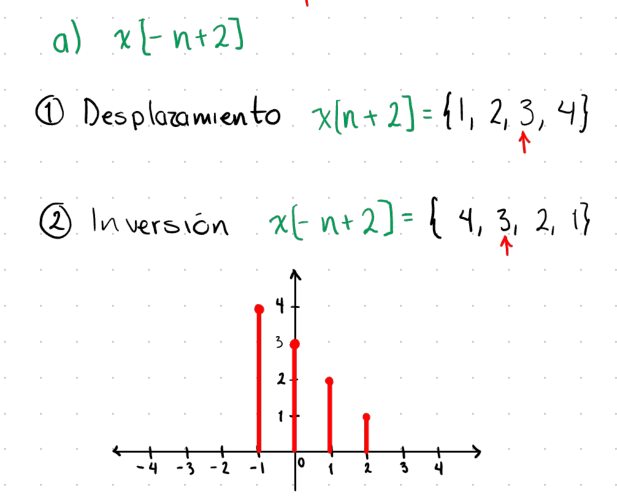

b) $x[3-n]$

/tmp/ipykernel_2306/2479361525.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_2306/2479361525.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_2306/2479361525.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()


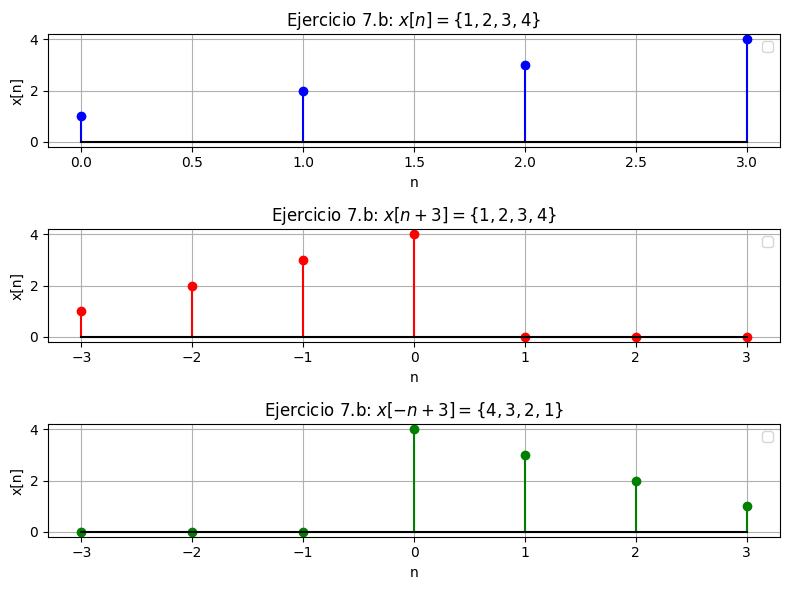

In [15]:
# Definiendo la funcion discreta
n = [0, 1, 2, 3]
xn = [1, 2, 3 ,4]

# Orden condiderando la combinación de transformaciones
# 1. Aplicar desplazamiento
# 2. Aplicar escalamiento / inversion

# Se implemento usando la fomra x[n-k]; si k = -3 -> x[n+3]
xn_desplazamiento, n_d = desplazamiento(xn, n, -3)
xn_des_inv, n_d_inv = inversion_tiempo(n_d, xn_desplazamiento)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 6))

ax1.stem(n, xn, linefmt='blue', markerfmt='b', basefmt='black')
ax1.set_title(r"Ejercicio 7.b: $x[n] = \{1,2,3,4\}$")
ax1.set_xlabel("n")
ax1.set_ylabel("x[n]")
ax1.grid(True)
ax1.legend()

ax2.stem(n_d, xn_desplazamiento, linefmt='red', markerfmt='ro', basefmt='black')
ax2.set_title(r"Ejercicio 7.b: $x[n+3] = \{1,2,3,4\}$")
ax2.set_xlabel("n")
ax2.set_ylabel("x[n]")
ax2.grid(True)
ax2.legend()

ax3.stem(n_d_inv, xn_des_inv, linefmt='green', markerfmt='g', basefmt='black')
ax3.set_title(r"Ejercicio 7.b: $x[-n+3] = \{4,3,2,1\}$")
ax3.set_xlabel("n")
ax3.set_ylabel("x[n]")
ax3.grid(True)
ax3.legend()

plt.tight_layout()
plt.show()

Resultados obtenidos a papel

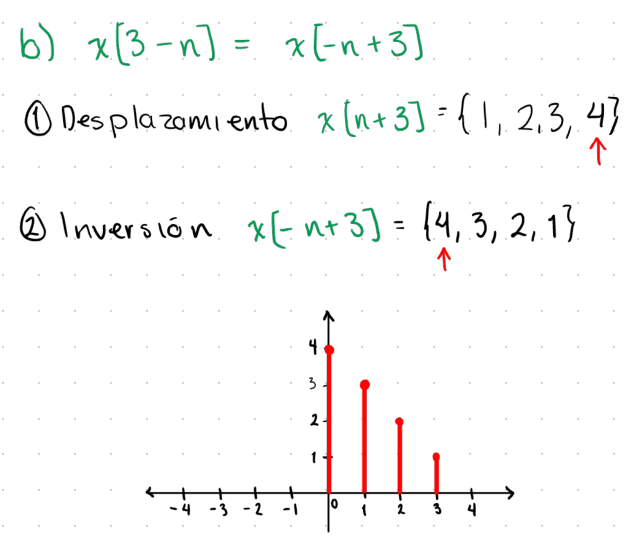

# Excercise 8:
Determine whether the following signals are energy signals or power signals:    Compute energy/power as appropriate.


a)  $\:x[n] = cos[(\pi /4)\,n]$

La señal coseno es infinita, por lo que se descarta que sea una señal de energía.

Al tener la señal en su forma discreta representada por una expresión para poder calcular la potencia se genera muchos valores de la señal para poder obtener su potencia

In [16]:
N = 8
# Numero de muestras para 200 periodos completos
L = 8 * 200
n = np.arange(-L, (L + 1), 1)
xn = np.cos((np.pi / 4) * n)

P = potencia(xn)
print(f"La potencia de la señal es:  \nP = {P}")

La potencia de la señal es:  
P = 0.500156201187129


Resultados obtenidos a papel:

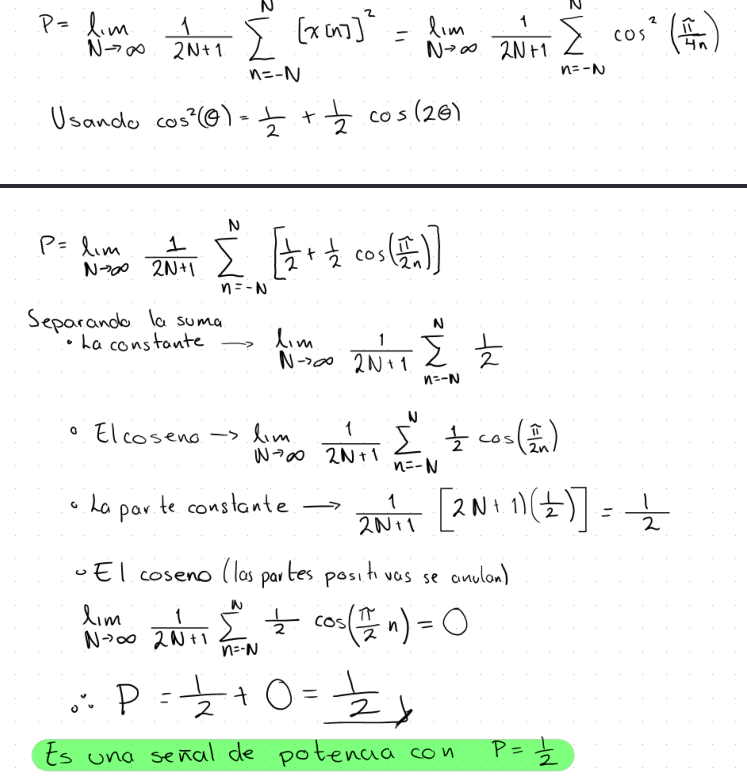


b) $\: x[n] = (1/2)^n\: u[n]$

A partir de la expresión de la señal se sabe que vale cero para $n < 0$ y empieza en 0, además de que es causal, por lo que se evalua si es una señal de energía

In [17]:
# Numero de muestras: 1000
L = 1000
n = np.arange(-L, (L + 1), 1)
xn = []

for i in n:
    xn.append(((0.5) ** i) * funcion_escalon(i) )

E = energia(xn)
print(f"La energia de la señal es:  \nE = {E}")

La energia de la señal es:  
E = 1.3333333333333333


Resultado obtenido a papel:

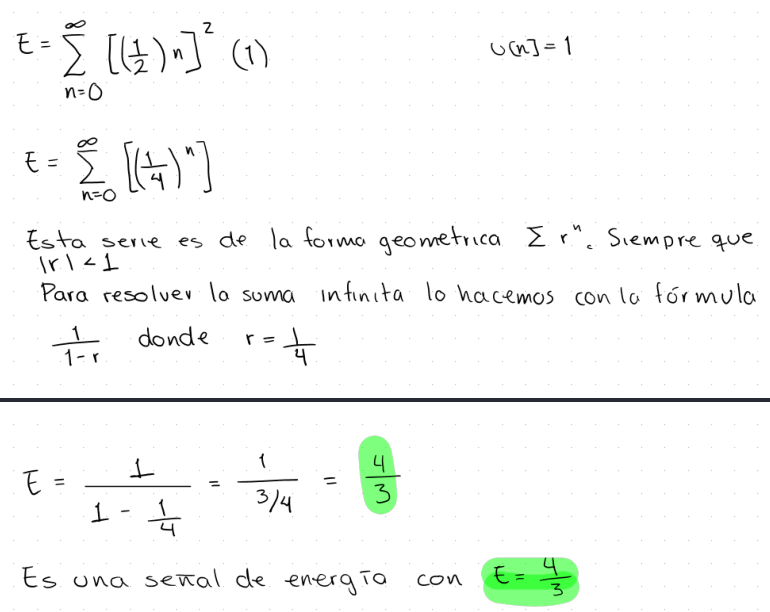

# Excercise 9:
Given $x[n] = (0.9)^{n} u[n]$

* Is this an energy o power signal?

A partir de la expresión de la señal se puede identificar que la señal vale $0$ para $n < 0$ además de que empieza $0$. Además es una señal causal por lo que se revisa primero si es una señal de energía

* Compute its total energy

In [18]:
# Numero de muestras: 1000
L = 1000
n = np.arange(-L, (L + 1), 1)
xn = []

for i in n:
    xn.append(((0.9) ** i) * funcion_escalon(i) )

E = energia(xn)
print(f"La energia de la señal es:  \nE = {E}")

La energia de la señal es:  
E = 5.2631578947368425


Resultados obtenidos a papel:

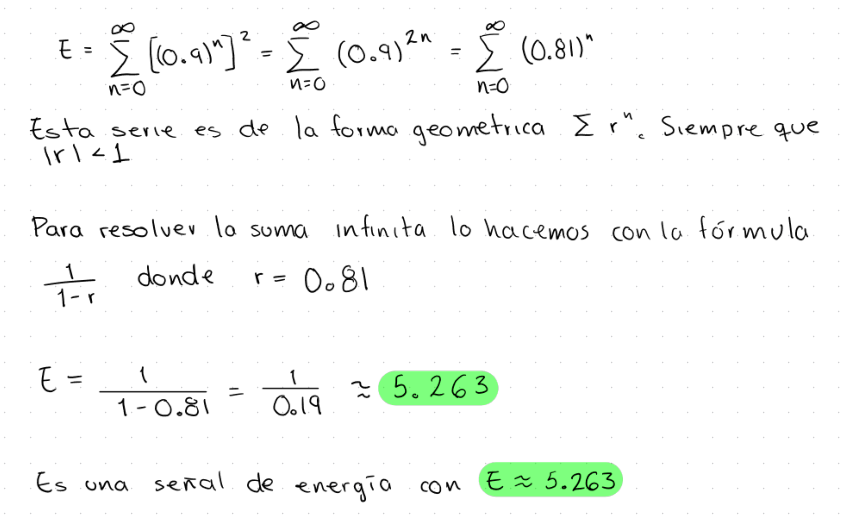


# Excercise 10:
A signal $x[n] = \{1,-1,2,-2\}$ for $n=0,1,2,3$.

- Plot the original signal.


/tmp/ipykernel_2306/1795805764.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


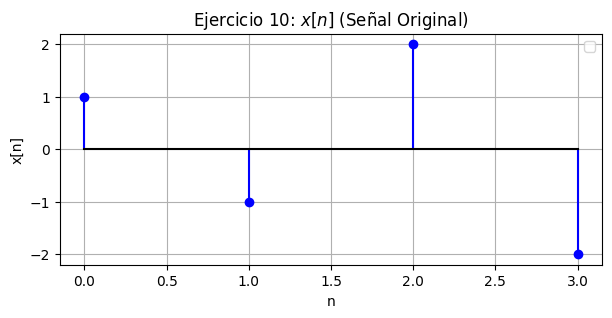

In [19]:
# Definiendo la funcion discreta
n = [0, 1, 2, 3]
xn = [1,-1,2,-2]

plt.stem(n, xn, linefmt='blue', markerfmt='b', basefmt='black')
plt.title(r"Ejercicio 10: $x[n]$ (Señal Original)")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.grid(True)
plt.legend()


plt.show()

Resultados y Graficas obtenidas a Mano

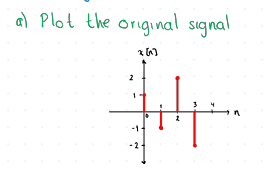

  - Apply time reversal → shift right by 2 samples → scale by factor 3.

/tmp/ipykernel_2306/771900185.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


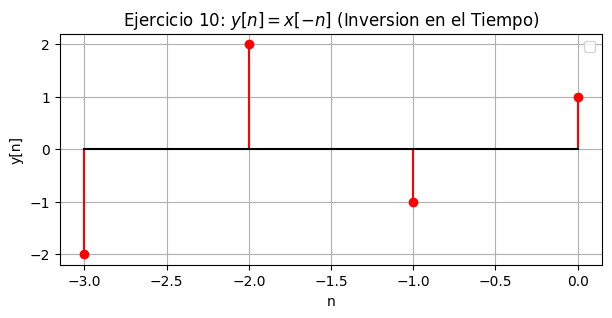

In [20]:
# Definiendo la funcion discreta
n = [0, 1, 2, 3]
xn = [1,-1,2,-2]
# Aplicando la primera operacion solicitada (Apply time reversal)
xn_inv, n_inv = inversion_tiempo(n, xn)

plt.stem(n_inv,xn_inv, linefmt='red', markerfmt='ro', basefmt='black')
plt.title(r"Ejercicio 10: $y[n] = x[-n]$ (Inversion en el Tiempo)")
plt.xlabel("n")
plt.ylabel("y[n]")
plt.grid(True)
plt.legend()
plt.show()

/tmp/ipykernel_2306/2517551706.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


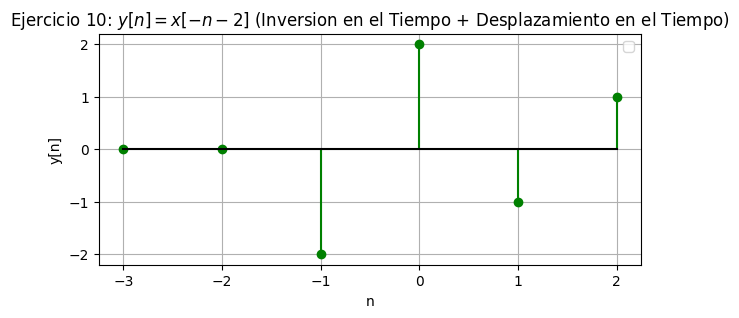

In [21]:

# Definiendo la funcion discreta
n = [0, 1, 2, 3]
xn = [1,-1,2,-2]

# Aplicando la primera y segunda operacion solicitada:
# (Apply Time Reversal)
xn_inv, n_inv = inversion_tiempo(n, xn)
# (shift right by 2 samples)
xn_inv_desp, n_inv_desp = desplazamiento(xn_inv, n_inv, 2)

plt.stem(n_inv_desp,xn_inv_desp, linefmt='green', markerfmt='g', basefmt='black')
plt.title(r"Ejercicio 10: $y[n] = x[-n-2]$ (Inversion en el Tiempo + Desplazamiento en el Tiempo)")
plt.xlabel("n")
plt.ylabel("y[n]")
plt.grid(True)
plt.legend()
plt.show()

Señal Resultante de Forma Explicita
[-3, -2, -1, 0, 1, 2]
[0, 0, -6, 6, -3, 3]


/tmp/ipykernel_2306/2677282557.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


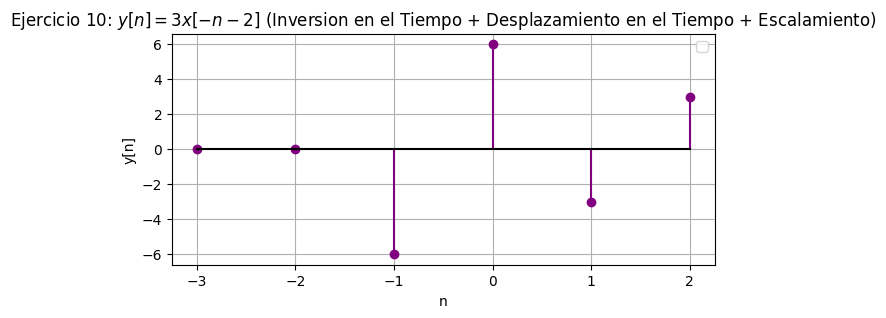

In [22]:
# Definiendo la funcion discreta
n = [0, 1, 2, 3]
xn = [1,-1,2,-2]
# Aplicando las 3 operaciones solicitadas en el orden indicado:
# (Apply Time Reversal)
xn_inv, n_inv = inversion_tiempo(n, xn)
# (shift right by 2 samples)
xn_inv_desp, n_inv_desp = desplazamiento(xn_inv, n_inv, 2)
# (scale by factor 3) Considerando un escalamiento en magnitud
xn_inv_desp_escal = []
for i in range(len(n_inv_desp)):
  xn_inv_desp_escal.append(xn_inv_desp[i]*3)

print("Señal Resultante de Forma Explicita")
print(n_inv_desp)
print(xn_inv_desp_escal)


plt.stem(n_inv_desp,xn_inv_desp_escal, linefmt='purple', markerfmt='o', basefmt='black')
plt.title(r"Ejercicio 10: $y[n] = 3x[-n-2]$ (Inversion en el Tiempo + Desplazamiento en el Tiempo + Escalamiento)")
plt.xlabel("n")
plt.ylabel("y[n]")
plt.grid(True)
plt.legend()
plt.show()

Señal Representada de Forma Explicita

$y[n] =  \{0,0,0-6,6,-3,3\}$ para $n=-3,-2,-1,0,1,2$

Resultados y Gráficas obtenidas en papel:

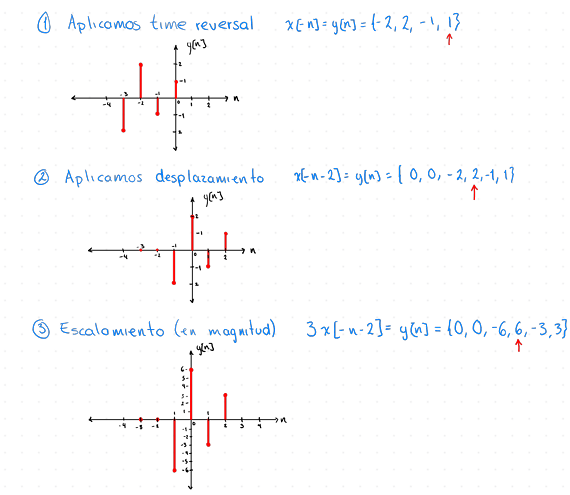

